In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
df = pd.read_csv("Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [81]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


In [82]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [83]:
# Create Copy of dataset for data cleaning 
df_clean = df.copy()
df_clean.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [84]:
# Check if dataset have any null values or not
df_clean.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [104]:
# Fill null values with mode values for the categoric values / String values
df_clean["Weather"] = df_clean["Weather"].fillna(df_clean["Weather"].mode()[0])
df_clean["Traffic_Level"] = df_clean["Traffic_Level"].fillna(df_clean["Weather"].mode()[0])
df_clean["Time_of_Day"] = df_clean["Time_of_Day"].fillna(df_clean["Time_of_Day"].mode()[0])
df_clean.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                    0
Traffic_Level              0
Time_of_Day                0
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [ ]:
# Fill null numeric column with median value
df_clean["Courier_Experience_yrs"] = df_clean["Courier_Experience_yrs"].fillna(df_clean["Courier_Experience_yrs"].median())
df_clean.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [ ]:
# Drop Order_ID column
df_clean.drop("Order_ID", axis= 1)
df_clean.value_counts()

Distance_km  Weather  Traffic_Level  Time_of_Day  Vehicle_Type  Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min
7.93         Windy    Low            Afternoon    Scooter       12                    1.0                     43                   1
16.42        Clear    Medium         Evening      Bike          20                    2.0                     84                   1
9.52         Foggy    Low            Night        Scooter       28                    1.0                     59                   1
7.44         Rainy    Medium         Afternoon    Scooter       5                     1.0                     37                   1
19.03        Clear    Low            Morning      Bike          16                    5.0                     68                   1
                                                                                                                                  ..
8.50         Clear    High           Evening      Car           13        

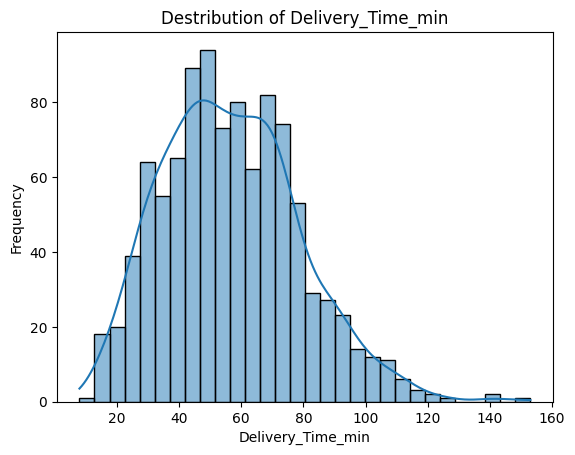

In [107]:
# Distribution of the Target Variable
plt.Figure(figsize= (6,4))
sns.histplot(df_clean["Delivery_Time_min"] ,kde= True, bins = 30)
plt.title("Destribution of Delivery_Time_min")
plt.xlabel("Delivery_Time_min")
plt.ylabel("Frequency")
plt.show()

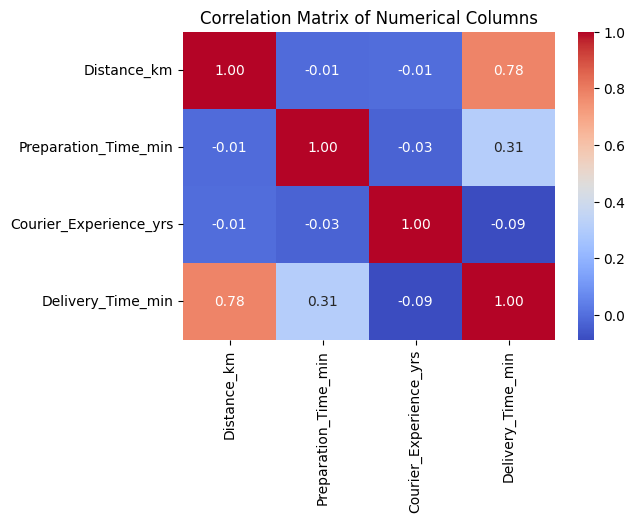

In [ ]:
# Correlation Matrix of Numerical Columns
plt.figure(figsize= (6,4))
sns.heatmap(df_clean.corr(numeric_only= True), annot= True, cmap= "coolwarm", fmt= ".2f")
plt.title("Correlation Matrix of Numerical Columns")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_6016\119726751.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Delivery_Time_min', data=df_clean, palette='viridis')
C:\Users\user\AppData\Local\Temp\ipykernel_6016\119726751.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Delivery_Time_min', data=df_clean, palette='viridis')
C:\Users\user\AppData\Local\Temp\ipykernel_6016\119726751.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Delivery_Time_min', data=df_clean, palette='viridis')
C:\Users\user\AppData\Loc

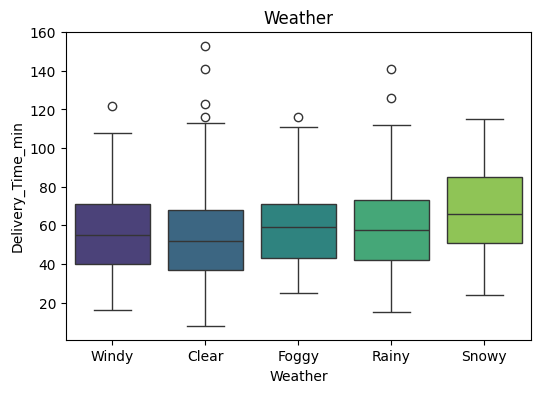

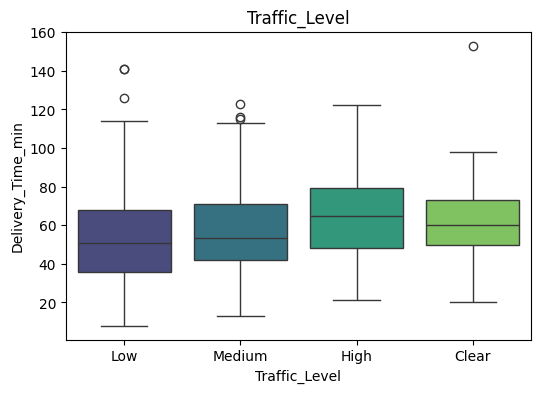

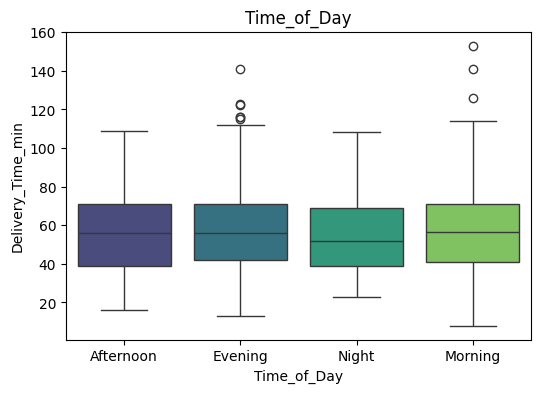

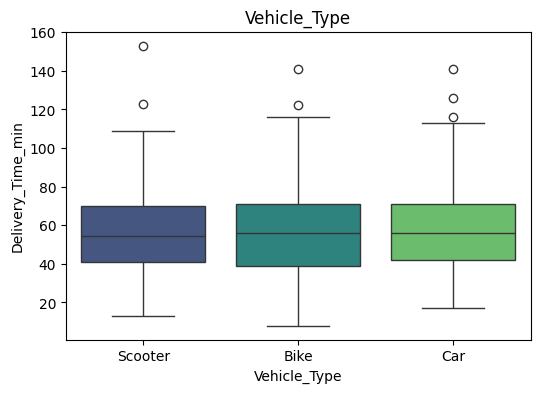

In [115]:
# Relation Between Categorical and Target Variable (Delivery_Time_min)
category_col = ["Weather", "Traffic_Level", "Time_of_Day", "Vehicle_Type"]

for col in category_col:
    plt.figure(figsize= (6,4))
    sns.boxplot(x=col, y='Delivery_Time_min', data=df_clean, palette='viridis')
    plt.title(col)


In [ ]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df_clean["Vehicle_Type"] = df_clean["Vehicle_Type"].map({"Scooter" : 0, "Bike" : 1, "Car" : 2})
df_clean["Time_of_Day"] = df_clean["Time_of_Day"].map({"Afternoon" : 0, "Evening" : 1, "Night" : 2, "Morning" : 3})

df_clean.info()

#df_clean["Weather"] = df["Weather"].map({""})


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 1000 non-null   str    
 3   Traffic_Level           1000 non-null   str    
 4   Time_of_Day             0 non-null      float64
 5   Vehicle_Type            0 non-null      float64
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(4), int64(3), str(2)
memory usage: 70.4 KB


In [ ]:
# Drop Order_ID column
df_clean.drop("Order_ID", axis= 1)
df_clean.value_counts()

Distance_km  Weather  Traffic_Level  Time_of_Day  Vehicle_Type  Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min
7.93         Windy    Low            Afternoon    Scooter       12                    1.0                     43                   1
16.42        Clear    Medium         Evening      Bike          20                    2.0                     84                   1
9.52         Foggy    Low            Night        Scooter       28                    1.0                     59                   1
7.44         Rainy    Medium         Afternoon    Scooter       5                     1.0                     37                   1
19.03        Clear    Low            Morning      Bike          16                    5.0                     68                   1
                                                                                                                                  ..
8.50         Clear    High           Evening      Car           13        

In [129]:
df_clean.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,NaN,NaN,12,1.0,43
1,738,16.42,Clear,Medium,NaN,NaN,20,2.0,84
2,741,9.52,Foggy,Low,NaN,NaN,28,1.0,59
3,661,7.44,Rainy,Medium,NaN,NaN,5,1.0,37
4,412,19.03,Clear,Low,NaN,NaN,16,5.0,68


In [134]:
# Step 1 - Copy fresh from original df (before any mapping was done)
df_clean["Vehicle_Type"] = df["Vehicle_Type"]
df_clean["Time_of_Day"] = df["Time_of_Day"]

# Step 2 - Check exact values
print(df_clean["Vehicle_Type"].unique())
print(df_clean["Time_of_Day"].unique())

# Step 3 - Clean and remap
df_clean["Vehicle_Type"] = df_clean["Vehicle_Type"].str.strip().str.title()
df_clean["Time_of_Day"] = df_clean["Time_of_Day"].str.strip().str.title()

# Label Encode for the Ordinal values ※ Ordinal means in Order
df_clean["Vehicle_Type"] = df_clean["Vehicle_Type"].map({"Scooter": 0, "Bike": 1, "Car": 2})
df_clean["Time_of_Day"] = df_clean["Time_of_Day"].map({"Morning": 0, "Afternoon": 1, "Evening": 2, "Night": 3})

<StringArray>
['Scooter', 'Bike', 'Car']
Length: 3, dtype: str
<StringArray>
['Afternoon', 'Evening', 'Night', 'Morning']
Length: 4, dtype: str


In [135]:
df_clean.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,1,0,12,1.0,43
1,738,16.42,Clear,Medium,2,1,20,2.0,84
2,741,9.52,Foggy,Low,3,0,28,1.0,59
3,661,7.44,Rainy,Medium,1,0,5,1.0,37
4,412,19.03,Clear,Low,0,1,16,5.0,68


In [136]:
df_clean.tail()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
995,107,8.50,Clear,High,2,2,13,3.0,54
996,271,16.28,Rainy,Low,0,0,8,9.0,71
997,861,15.62,Snowy,High,2,0,26,2.0,81
998,436,14.17,Clear,Low,1,1,8,0.0,55
999,103,6.63,Foggy,Low,3,0,24,3.0,58


In [137]:
# Reverse Vehicle_Type Columns
df_clean["Vehicle_Type"] = df["Vehicle_Type"]
df_clean["Vehicle_Type"].head()

0    Scooter
1       Bike
2    Scooter
3    Scooter
4       Bike
Name: Vehicle_Type, dtype: str

In [138]:
df_clean["Vehicle_Type"].isnull().sum()

np.int64(0)

In [144]:
df_clean.head()

,Order_ID,Distance_km,Traffic_Level,Time_of_Day,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,Low,1,12,1.0,43,False,False,False,False,True,False,False,True
1,738,16.42,Medium,2,20,2.0,84,True,False,False,False,False,True,False,False
2,741,9.52,Low,3,28,1.0,59,False,True,False,False,False,False,False,True
3,661,7.44,Medium,1,5,1.0,37,False,False,True,False,False,False,False,True
4,412,19.03,Low,0,16,5.0,68,True,False,False,False,False,True,False,False


In [145]:
# Label Endocing for Ordinal Values Columns
df_clean["Traffic_Level"] = df_clean["Traffic_Level"].map({"Low" : 0, "Medium" : 1, "High" : 2})
df_clean["Traffic_Level"].head()

0    0.0
1    1.0
2    0.0
3    1.0
4    0.0
Name: Traffic_Level, dtype: float64

In [146]:
df_clean.head()

,Order_ID,Distance_km,Traffic_Level,Time_of_Day,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,0.0,1,12,1.0,43,False,False,False,False,True,False,False,True
1,738,16.42,1.0,2,20,2.0,84,True,False,False,False,False,True,False,False
2,741,9.52,0.0,3,28,1.0,59,False,True,False,False,False,False,False,True
3,661,7.44,1.0,1,5,1.0,37,False,False,True,False,False,False,False,True
4,412,19.03,0.0,0,16,5.0,68,True,False,False,False,False,True,False,False


In [147]:
df_clean = df_clean.astype({col: int for col in df_clean.select_dtypes(include="bool").columns})

In [148]:
df_clean.head()

,Order_ID,Distance_km,Traffic_Level,Time_of_Day,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,0.0,1,12,1.0,43,0,0,0,0,1,0,0,1
1,738,16.42,1.0,2,20,2.0,84,1,0,0,0,0,1,0,0
2,741,9.52,0.0,3,28,1.0,59,0,1,0,0,0,0,0,1
3,661,7.44,1.0,1,5,1.0,37,0,0,1,0,0,0,0,1
4,412,19.03,0.0,0,16,5.0,68,1,0,0,0,0,1,0,0


In [149]:
df_clean.isnull().sum()

Order_ID                   0
Distance_km                0
Traffic_Level             30
Time_of_Day                0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
Weather_Clear              0
Weather_Foggy              0
Weather_Rainy              0
Weather_Snowy              0
Weather_Windy              0
Vehicle_Type_Bike          0
Vehicle_Type_Car           0
Vehicle_Type_Scooter       0
dtype: int64

In [152]:
df_clean["Traffic_Level"] = df_clean["Traffic_Level"].fillna(df_clean["Traffic_Level"].mode()[0])
df_clean["Traffic_Level"].isnull().sum()

np.int64(0)

In [153]:
df_clean["Traffic_Level"] = df_clean["Traffic_Level"].astype(int)
df_clean.head()

,Order_ID,Distance_km,Traffic_Level,Time_of_Day,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,0,1,12,1.0,43,0,0,0,0,1,0,0,1
1,738,16.42,1,2,20,2.0,84,1,0,0,0,0,1,0,0
2,741,9.52,0,3,28,1.0,59,0,1,0,0,0,0,0,1
3,661,7.44,1,1,5,1.0,37,0,0,1,0,0,0,0,1
4,412,19.03,0,0,16,5.0,68,1,0,0,0,0,1,0,0


In [156]:
# Drop Order_ID
df_clean = df_clean.drop(columns= ["Order_ID"])
df_clean.head()

,Distance_km,Traffic_Level,Time_of_Day,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,0,1,12,1.0,43,0,0,0,0,1,0,0,1
1,16.42,1,2,20,2.0,84,1,0,0,0,0,1,0,0
2,9.52,0,3,28,1.0,59,0,1,0,0,0,0,0,1
3,7.44,1,1,5,1.0,37,0,0,1,0,0,0,0,1
4,19.03,0,0,16,5.0,68,1,0,0,0,0,1,0,0


In [ ]:
# Feature Selection
from scipy.stats import f_oneway

numerical_cols = df.select_dtypes(include=np.number).columns.tolist() 


if 'Delivery_Time_min' in numerical_cols:
    numerical_cols.remove('Delivery_Time_min')

print("Correlation with Delivery_Time_min:")
print(df[numerical_cols + ['Delivery_Time_min']].corr()['Delivery_Time_min'].sort_values(ascending=False).drop('Delivery_Time_min'))

# ANOVA for categorical
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
for col in categorical_cols:
    groups = [df['Delivery_Time_min'][df[col] == category] for category in df[col].unique()]
    f_statistic, p_value = f_oneway(*groups)
    print(f"{col}: p-value = {p_value:.4f}", "✅ Significant" if p_value < 0.05 else "❌ Not Significant")

Distance_km               float64
Weather                       str
Traffic_Level                 str
Time_of_Day                   str
Vehicle_Type                  str
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object
['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']
Correlation with Delivery_Time_min:
Distance_km               0.780998
Preparation_Time_min      0.307350
Courier_Experience_yrs   -0.089111
Name: Delivery_Time_min, dtype: float64
Weather: p-value = 0.0000 ✅ Significant
Traffic_Level: p-value = 0.0000 ✅ Significant
Time_of_Day: p-value = 0.7915 ❌ Not Significant
Vehicle_Type: p-value = 0.5549 ❌ Not Significant


In [163]:
# Drop columns with less relation between input and output variable
df_clean = df_clean.drop(columns= ["Courier_Experience_yrs", "Time_of_Day"])
df_clean.head()

,Distance_km,Traffic_Level,Preparation_Time_min,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,0,12,43,0,0,0,0,1,0,0,1
1,16.42,1,20,84,1,0,0,0,0,1,0,0
2,9.52,0,28,59,0,1,0,0,0,0,0,1
3,7.44,1,5,37,0,0,1,0,0,0,0,1
4,19.03,0,16,68,1,0,0,0,0,1,0,0


In [164]:
df_clean = df_clean.drop(columns= ["Vehicle_Type_Bike", "Vehicle_Type_Car", "Vehicle_Type_Scooter"])
df_clean.head()

,Distance_km,Traffic_Level,Preparation_Time_min,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy
0,7.93,0,12,43,0,0,0,0,1
1,16.42,1,20,84,1,0,0,0,0
2,9.52,0,28,59,0,1,0,0,0
3,7.44,1,5,37,0,0,1,0,0
4,19.03,0,16,68,1,0,0,0,0


In [165]:
df_clean.columns.tolist()

['Distance_km',
 'Traffic_Level',
 'Preparation_Time_min',
 'Delivery_Time_min',
 'Weather_Clear',
 'Weather_Foggy',
 'Weather_Rainy',
 'Weather_Snowy',
 'Weather_Windy']

In [170]:
# Feature Scaling

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


df_clean["Distance_km"] = scaler.fit_transform(df_clean[["Distance_km"]])
df_clean["Traffic_Level"] = scaler.fit_transform(df_clean[["Traffic_Level"]])
df_clean["Preparation_Time_min"] = scaler.fit_transform(df_clean[["Preparation_Time_min"]])

df_clean.head()

,Distance_km,Traffic_Level,Preparation_Time_min,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy
0,0.378351,0.0,0.291667,43,0,0,0,0,1
1,0.815979,0.5,0.625000,84,1,0,0,0,0
2,0.460309,0.0,0.958333,59,0,1,0,0,0
3,0.353093,0.5,0.000000,37,0,0,1,0,0
4,0.950515,0.0,0.458333,68,1,0,0,0,0


In [ ]:
# Split X and y
X = df_clean.drop(columns = ["Delivery_Time_min"])
y = df_clean["Delivery_Time_min"]

display(X)
display(y)

,Distance_km,Traffic_Level,Preparation_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy
0,0.378351,0.0,0.291667,0,0,0,0,1
1,0.815979,0.5,0.625000,1,0,0,0,0
2,0.460309,0.0,0.958333,0,1,0,0,0
3,0.353093,0.5,0.000000,0,0,1,0,0
4,0.950515,0.0,0.458333,1,0,0,0,0
...,...,...,...,...,...,...,...,...
995,0.407732,1.0,0.333333,1,0,0,0,0
996,0.808763,0.0,0.125000,0,0,1,0,0
997,0.774742,1.0,0.875000,0,0,0,1,0
998,0.700000,0.0,0.125000,1,0,0,0,0


0      43
1      84
2      59
3      37
4      68
       ..
995    54
996    71
997    81
998    55
999    58
Name: Delivery_Time_min, Length: 1000, dtype: int64

In [ ]:
# Train Test Split  
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42 )


print("X_train:", X_train.shape)  # 800 rows
print("X_test:", X_test.shape)    # 200 rows
print("y_train:", y_train.shape)  # 800 rows
print("y_test:", y_test.shape)    # 200 rows

X_train: (800, 8)
X_test: (200, 8)
y_train: (800,)
y_test: (200,)


In [ ]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results:
MAE: 6.088568640229489
R2 Score: 0.8225545150844054


In [177]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Results:
MAE: 7.224449999999999
R2 Score: 0.7653285246832813


In [179]:
# XGBoost Regressor
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("R2 Score:", r2_score(y_test, y_pred_xgb))

XGBoost Results:
MAE: 8.466962814331055
R2 Score: 0.6713955402374268


In [180]:
results = {
    "Linear Regression": r2_score(y_test, y_pred_lr),
    "Random Forest":     r2_score(y_test, y_pred_rf),
    "XGBoost":           r2_score(y_test, y_pred_xgb)
}

for model, score in results.items():
    print(f"{model}: R2 = {score:.4f}")

Linear Regression: R2 = 0.8226
Random Forest: R2 = 0.7653
XGBoost: R2 = 0.6714
